# Day-ahead price covariance

Pairwise covariance and correlation of hourly day-ahead prices for every bidding zone in
`datasets/nordic_baltic_clean_hourly_local.parquet`, rendered as heat-shaded matrices.

The cleaned file contains seven zones: NO2, SE3, SE4, DK1, DK2, DE_LU and NL. Data cleaning
has already produced the common 24-hour naive `Europe/Copenhagen` delivery-day grid used by
LEAR, the DNNs, and this analysis.

In [17]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.robust import mad

CLEAN = Path("datasets/nordic_baltic_clean_hourly_local.parquet")

# Zones roughly north to south, so the matrix blocks read cleanly.
ZONE_ORDER = ["NO2", "SE3", "SE4", "DK1", "DK2", "DE_LU", "NL"]

pd.set_option("display.max_columns", 40)

## 1. Load the price panel

The cleaned parquet is long-form, complete, and already normalized to naive `Europe/Copenhagen`
local market time. It contains exactly 24 rows per delivery day; spring interpolation and autumn
averaging were applied once in `data_cleaning_v2.ipynb`.

In [18]:
clean = pd.read_parquet(CLEAN)
price_rows = clean.loc[clean["variable"] == "price"]
panel = price_rows.pivot(
    index="timestamp_local", columns="zone", values="value"
).sort_index()
panel = panel[[zone for zone in ZONE_ORDER if zone in panel.columns]]

per_day = price_rows.groupby(price_rows["timestamp_local"].dt.normalize()).size()
assert per_day.eq(24 * panel.shape[1]).all(), "price panel is not 24 hours per local day"
assert not price_rows.duplicated(["series", "timestamp_local"]).any()

print(f"{panel.shape[0]:,} local hourly rows x {panel.shape[1]} zones")
print(f"{panel.index.min()}  ->  {panel.index.max()}")
print("DST normalization was applied during data cleaning")
panel.tail()

59,160 local hourly rows x 7 zones
2019-01-01 00:00:00  ->  2025-09-30 23:00:00
DST normalization was applied during data cleaning


zone,NO2,SE3,SE4,DK1,DK2,DE_LU,NL
timestamp_local,,,,,,,
2025-09-30 19:00:00,88.10,193.57,231.30,357.77,357.35,357.77,312.00
2025-09-30 20:00:00,96.60,100.57,118.33,147.28,147.19,147.28,139.56
2025-09-30 21:00:00,82.87,88.25,102.48,116.04,116.01,116.04,110.00
2025-09-30 22:00:00,72.38,79.04,92.35,101.63,101.61,101.63,98.00
2025-09-30 23:00:00,67.62,63.18,73.62,92.54,92.48,92.54,90.00


## 2. Coverage and dispersion by zone

Every retained price series spans the same local delivery window and contains exactly 59,160 model
hours after DST normalization. The diagonal of the covariance matrix is the square of `std` below,
so this table is the reference for reading the matrix.

In [19]:
coverage = pd.DataFrame({
    "obs": panel.count(),
    "first_hour": panel.apply(lambda s: s.first_valid_index()),
    "last_hour": panel.apply(lambda s: s.last_valid_index()),
    "mean": panel.mean(),
    "std": panel.std(),
    "min": panel.min(),
    "max": panel.max(),
})
coverage.index.name = "zone"

(coverage.style
    .format({"obs": "{:,.0f}", "mean": "{:,.2f}", "std": "{:,.2f}",
             "min": "{:,.2f}", "max": "{:,.2f}",
             "first_hour": "{:%Y-%m-%d %H:%M}", "last_hour": "{:%Y-%m-%d %H:%M}"})
    .background_gradient(cmap="Blues", subset=["std"])
    .set_caption("Hourly day-ahead prices, EUR/MWh"))

,obs,first_hour,last_hour,mean,std,min,max
zone,,,,,,,
NO2,"59,160",2019-01-01 00:00,2025-09-30 23:00,75.89,82.89,-61.84,898.25
SE3,"59,160",2019-01-01 00:00,2025-09-30 23:00,55.46,69.68,-60.04,799.97
SE4,"59,160",2019-01-01 00:00,2025-09-30 23:00,67.66,78.26,-60.04,799.97
DK1,"59,160",2019-01-01 00:00,2025-09-30 23:00,87.10,91.66,-440.10,936.28
DK2,"59,160",2019-01-01 00:00,2025-09-30 23:00,85.82,91.22,-60.04,936.31
DE_LU,"59,160",2019-01-01 00:00,2025-09-30 23:00,94.81,95.14,-500.00,936.28
NL,"59,160",2019-01-01 00:00,2025-09-30 23:00,97.20,93.51,-500.00,872.96


## 3. Conditionally coloured covariance matrix

`DataFrame.cov` uses pairwise-complete observations, so each pair is estimated on every hour where
both zones quote. `axis=None` puts the whole matrix on one colour scale instead of shading each
column independently — that is what makes the blocks comparable across the table.

In [20]:
cov = panel.cov()
corr = panel.corr()

# Pairwise observation count behind each estimate.
present = panel.notna().astype("int64")
pair_obs = present.T @ present


def shade_matrix(matrix, *, cmap="Blues", fmt="{:,.0f}", caption=None, vmin=None, vmax=None):
    """Heat-shade a square matrix on one shared scale and outline the diagonal."""
    diagonal = pd.DataFrame(
        np.where(np.eye(len(matrix), dtype=bool), "border: 2px solid #0e1113;", ""),
        index=matrix.index, columns=matrix.columns,
    )
    return (matrix.style
            .background_gradient(cmap=cmap, axis=None, vmin=vmin, vmax=vmax)
            .apply(lambda _: diagonal, axis=None)
            .format(fmt)
            .set_caption(caption)
            .set_table_styles([
                {"selector": "caption",
                 "props": "caption-side: top; font-weight: 600; padding-bottom: 8px;"},
                {"selector": "th", "props": "font-weight: 500; text-align: center;"},
                {"selector": "td",
                 "props": "text-align: right; font-variant-numeric: tabular-nums;"},
            ]))


shade_matrix(cov, caption="Covariance of hourly day-ahead prices, (EUR/MWh)² — diagonal is variance")

zone,NO2,SE3,SE4,DK1,DK2,DE_LU,NL
zone,,,,,,,
NO2,"6,871","4,341","5,034","6,996","6,731","7,119","6,987"
SE3,"4,341","4,855","4,952","4,819","4,940","4,805","4,614"
SE4,"5,034","4,952","6,125","5,888","6,046","5,866","5,584"
DK1,"6,996","4,819","5,888","8,401","8,142","8,448","8,081"
DK2,"6,731","4,940","6,046","8,142","8,321","8,167","7,750"
DE_LU,"7,119","4,805","5,866","8,448","8,167","9,052","8,630"
NL,"6,987","4,614","5,584","8,081","7,750","8,630","8,744"


## 4. The same matrix as correlation

Covariance magnitudes are driven by price level, so the volatile continental zones dominate the
shading above regardless of how tightly they actually move together. Correlation strips the scale
out, and that is where the market structure shows up.

In [21]:
shade_matrix(
    corr,
    fmt="{:.2f}",
    vmin=0.0, vmax=1.0,
    caption="Correlation of hourly day-ahead prices — diagonal is unity",
)

zone,NO2,SE3,SE4,DK1,DK2,DE_LU,NL
zone,,,,,,,
NO2,1.00,0.75,0.78,0.92,0.89,0.90,0.90
SE3,0.75,1.00,0.91,0.75,0.78,0.72,0.71
SE4,0.78,0.91,1.00,0.82,0.85,0.79,0.76
DK1,0.92,0.75,0.82,1.00,0.97,0.97,0.94
DK2,0.89,0.78,0.85,0.97,1.00,0.94,0.91
DE_LU,0.90,0.72,0.79,0.97,0.94,1.00,0.97
NL,0.90,0.71,0.76,0.94,0.91,0.97,1.00


## 5. Observations behind each pair

All seven price series share the same complete local delivery grid, so every covariance and
correlation estimate should use the full 59,160-hour sample. This matrix makes that invariant
explicit.

In [22]:
shade_matrix(pair_obs, cmap="Greys", caption="Pairwise complete observations (hours)")

zone,NO2,SE3,SE4,DK1,DK2,DE_LU,NL
zone,,,,,,,
NO2,"59,160","59,160","59,160","59,160","59,160","59,160","59,160"
SE3,"59,160","59,160","59,160","59,160","59,160","59,160","59,160"
SE4,"59,160","59,160","59,160","59,160","59,160","59,160","59,160"
DK1,"59,160","59,160","59,160","59,160","59,160","59,160","59,160"
DK2,"59,160","59,160","59,160","59,160","59,160","59,160","59,160"
DE_LU,"59,160","59,160","59,160","59,160","59,160","59,160","59,160"
NL,"59,160","59,160","59,160","59,160","59,160","59,160","59,160"


## 6. Strongest and weakest pairs

In [23]:
upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
pairs = (upper.rename_axis(index="zone_a", columns="zone_b")
              .stack()
              .dropna()          # drop the masked lower triangle and diagonal
              .rename("corr")
              .reset_index()
              .sort_values("corr", ascending=False, ignore_index=True))
pairs["cov"] = [cov.loc[a, b] for a, b in zip(pairs["zone_a"], pairs["zone_b"])]
pairs["obs"] = [pair_obs.loc[a, b] for a, b in zip(pairs["zone_a"], pairs["zone_b"])]

(pd.concat([pairs.head(5), pairs.tail(5)])
   .style
   .format({"corr": "{:.3f}", "cov": "{:,.0f}", "obs": "{:,.0f}"})
   .background_gradient(cmap="Blues", subset=["corr"], vmin=0.0, vmax=1.0)
   .hide(axis="index")
   .set_caption("Five most and five least correlated zone pairs"))

zone_a,zone_b,corr,cov,obs
DK1,DK2,0.974,"8,142","59,160"
DE_LU,NL,0.970,"8,630","59,160"
DK1,DE_LU,0.969,"8,448","59,160"
DK1,NL,0.943,"8,081","59,160"
DK2,DE_LU,0.941,"8,167","59,160"
SE4,NL,0.763,"5,584","59,160"
SE3,DK1,0.755,"4,819","59,160"
NO2,SE3,0.752,"4,341","59,160"
SE3,DE_LU,0.725,"4,805","59,160"
SE3,NL,0.708,"4,614","59,160"


## 7. The variance-stabilizing transformation LEAR applies

LEAR does not fit on prices directly. `_lear.py` scales both the target and the non-dummy
regressors with epftoolbox's `'Invariant'` scaler, which is a median/MAD standardisation followed by
`arcsinh`:

$$z = \operatorname{arcsinh}\!\left(\frac{p - \operatorname{median}(p)}{\operatorname{MAD}(p)}\right)$$

`MAD` here is `statsmodels.robust.mad`, which divides the median absolute deviation by 0.6745 so it
estimates the same scale as a standard deviation under normality. The scaler is fitted on a 2-D
`(days × 24)` array, so the median and MAD are computed **per delivery hour** — hour 03 gets its own
centre and scale, independent of hour 18. The reconstruction below reproduces that column-wise fit.

`arcsinh` is what does the stabilising work: it is near-linear inside roughly ±1 MAD and grows
logarithmically beyond, so ordinary hours pass through nearly untouched while spikes are compressed.
Unlike a log transform it is defined for negatives, which day-ahead prices need.

One difference from a backtest: LEAR refits the scaler on each rolling calibration window. Here it is
fitted once on 2024 itself, so the panels show the transformation rather than any particular
recalibration.

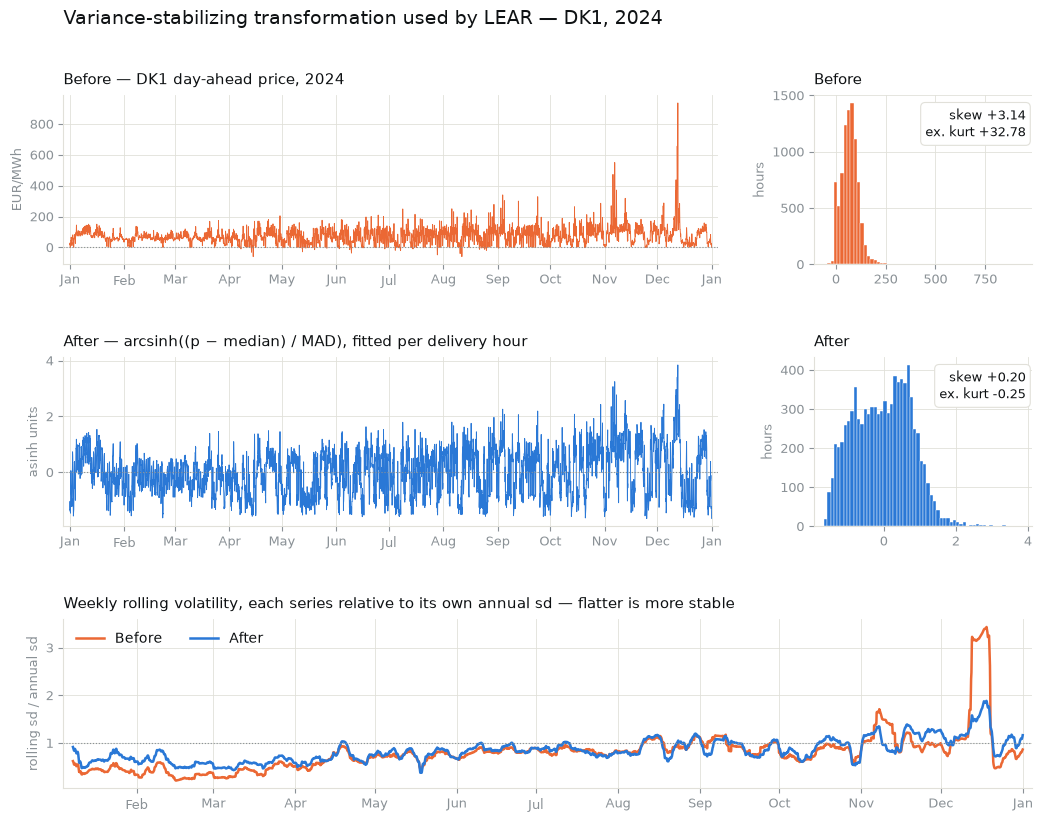

,before,after
skewness,3.14,0.20
excess kurtosis,32.78,-0.25
rolling-sd range,3.22,1.51


In [24]:
ZONE, YEAR = "DK1", "2024"
RAW_C, TRS_C = "#eb6834", "#2a78d6"          # before / after
INK, MUTED, GRID = "#0e1113", "#8a9196", "#e1e0d9"
WIN = 24 * 7                                  # one week, for the rolling panel

raw = panel.loc[YEAR, ZONE]

# epftoolbox InvariantScaler: median/MAD per delivery hour, then arcsinh.
Y = raw.to_numpy().reshape(-1, 24)
centre, scale = np.median(Y, axis=0), mad(Y, axis=0)
transformed = pd.Series(np.arcsinh((Y - centre) / scale).reshape(-1), index=raw.index)

fig, ax = plt.subplot_mosaic(
    [["raw", "hraw"], ["trs", "htrs"], ["roll", "roll"]],
    figsize=(12.5, 9), width_ratios=[3, 1],
    gridspec_kw={"hspace": 0.55, "wspace": 0.22},
)
fig.patch.set_facecolor("white")
for a in ax.values():
    a.set_facecolor("white")
    a.spines[["top", "right"]].set_visible(False)
    a.spines[["left", "bottom"]].set_color(GRID)
    a.tick_params(colors=MUTED, labelsize=9)
    a.grid(True, color=GRID, lw=0.6)
    a.set_axisbelow(True)

for key, series, colour, ylab, title in [
    ("raw", raw, RAW_C, "EUR/MWh", f"Before — {ZONE} day-ahead price, {YEAR}"),
    ("trs", transformed, TRS_C, "asinh units",
     "After — arcsinh((p − median) / MAD), fitted per delivery hour"),
]:
    a = ax[key]
    a.plot(series.index, series.to_numpy(), color=colour, lw=0.65)
    a.axhline(0, color=MUTED, lw=0.8, ls=":")
    a.set_ylabel(ylab, fontsize=9.5, color=MUTED)
    a.set_title(title, fontsize=11, color=INK, loc="left", pad=8)
    a.xaxis.set_major_locator(mdates.MonthLocator())
    a.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
    a.margins(x=0.01)

for key, series, colour, title in [
    ("hraw", raw, RAW_C, "Before"),
    ("htrs", transformed, TRS_C, "After"),
]:
    a = ax[key]
    a.hist(series.to_numpy(), bins=60, color=colour, edgecolor="white", linewidth=0.3)
    a.set_ylabel("hours", fontsize=9.5, color=MUTED)
    a.set_title(title, fontsize=11, color=INK, loc="left", pad=8)
    a.annotate(f"skew {series.skew():+.2f}\nex. kurt {series.kurt():+.2f}",
               xy=(0.97, 0.93), xycoords="axes fraction", ha="right", va="top",
               fontsize=9.5, color=INK,
               bbox=dict(boxstyle="round,pad=.35", fc="white", ec=GRID, lw=0.8))

a = ax["roll"]
for series, colour, label in [(raw, RAW_C, "Before"), (transformed, TRS_C, "After")]:
    a.plot(series.index, (series.rolling(WIN).std() / series.std()).to_numpy(),
           color=colour, lw=1.8, label=label)
a.axhline(1, color=MUTED, lw=0.8, ls=":")
a.set_ylabel("rolling sd / annual sd", fontsize=9.5, color=MUTED)
a.set_title("Weekly rolling volatility, each series relative to its own annual sd — "
            "flatter is more stable", fontsize=11, color=INK, loc="left", pad=8)
a.xaxis.set_major_locator(mdates.MonthLocator())
a.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
a.margins(x=0.01)
for text in a.legend(frameon=False, fontsize=10, loc="upper left", ncol=2).get_texts():
    text.set_color(INK)

fig.suptitle(f"Variance-stabilizing transformation used by LEAR — {ZONE}, {YEAR}",
             fontsize=13.5, color=INK, x=0.125, ha="left", y=0.975)
plt.show()

spread = lambda s: ((s.rolling(WIN).std() / s.std()).max()
                    - (s.rolling(WIN).std() / s.std()).min())
pd.DataFrame({
    "before": [raw.skew(), raw.kurt(), spread(raw)],
    "after": [transformed.skew(), transformed.kurt(), spread(transformed)],
}, index=["skewness", "excess kurtosis", "rolling-sd range"]).round(2)

In [26]:
TEST_START = pd.Timestamp("2023-10-01")
TEST_END = pd.Timestamp("2025-09-30 23:00")
CALIBRATION_END = TEST_START - pd.Timedelta(hours=1)

prices = panel[["DK1", "DK2"]]
periods = {
    "Full period": prices,
    "Calibration": prices.loc[:CALIBRATION_END],
    "Testing": prices.loc[TEST_START:TEST_END],
}
periods.update({str(year): group for year, group in prices.groupby(prices.index.year)})

price_summaries = {}
for zone in prices.columns:
    columns = {}
    for period, values in periods.items():
        series = values[zone].dropna()
        columns[period] = {
            "Mean": series.mean(),
            "Median": series.median(),
            "Std. dev.": series.std(),
            "Negative values": int(series.lt(0).sum()),
        }
    price_summaries[zone] = pd.DataFrame(columns)

for zone, summary in price_summaries.items():
    styled = (summary.style
        .format("{:.2f}", subset=pd.IndexSlice[["Mean", "Median", "Std. dev."], :])
        .format("{:,.0f}", subset=pd.IndexSlice[["Negative values"], :])
        .set_caption(
            f"{zone} hourly day-ahead prices (EUR/MWh) — "
            f"calibration {prices.index.min():%Y-%m-%d} to {CALIBRATION_END:%Y-%m-%d}; "
            f"testing {TEST_START:%Y-%m-%d} to {TEST_END:%Y-%m-%d}"
        ))
    display(styled)

,Full period,Calibration,Testing,2019,2020,2021,2022,2023,2024,2025
Mean,87.10,92.48,74.35,38.50,24.98,88.13,219.05,86.83,70.64,79.97
Median,61.45,53.17,77.07,38.75,23.86,73.26,190.62,92.04,67.89,86.94
Std. dev.,91.66,103.71,50.82,13.15,17.43,64.78,145.44,48.82,50.16,52.38
Negative values,"1,516",652,864,132,192,87,38,281,375,411


,Full period,Calibration,Testing,2019,2020,2021,2022,2023,2024,2025
Mean,85.82,90.54,74.62,39.84,28.41,87.91,210.17,81.26,70.86,81.34
Median,58.16,50.97,76.47,39.57,25.48,70.99,187.01,85.07,68.72,86.84
Std. dev.,91.22,102.87,52.71,12.65,19.72,67.76,150.21,50.12,52.21,52.99
Negative values,969,363,606,95,89,24,5,231,275,250


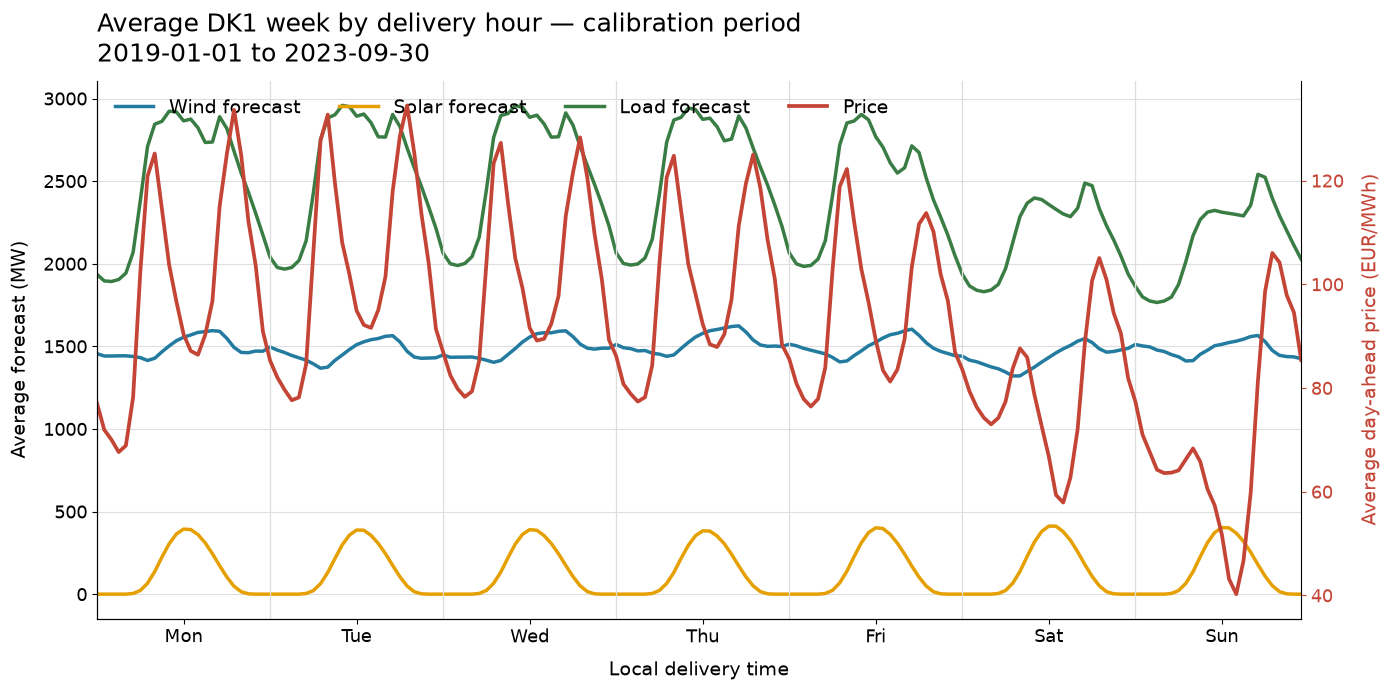

In [30]:
CALIBRATION_START = prices.index.min()
dk1_calibration = clean.loc[
    clean["zone"].eq("DK1")
    & clean["timestamp_local"].between(CALIBRATION_START, CALIBRATION_END)
].copy()

price_calibration = (dk1_calibration.loc[dk1_calibration["variable"].eq("price")]
                     .set_index("timestamp_local")["value"])
load_calibration = (dk1_calibration.loc[dk1_calibration["variable"].eq("load_forecast")]
                    .set_index("timestamp_local")["value"])
solar_calibration = (dk1_calibration.loc[dk1_calibration["psr_type"].eq("solar")]
                     .set_index("timestamp_local")["value"])
wind_calibration = (
    dk1_calibration.loc[
        dk1_calibration["psr_type"].isin(["wind_onshore", "wind_offshore"])
    ]
    .pivot(index="timestamp_local", columns="psr_type", values="value")
    .sum(axis=1, min_count=2)
)

hourly_calibration = pd.DataFrame({
    "Wind forecast": wind_calibration,
    "Solar forecast": solar_calibration,
    "Load forecast": load_calibration,
    "Price": price_calibration,
})
hour_of_week = hourly_calibration.index.dayofweek * 24 + hourly_calibration.index.hour
average_week_calibration = hourly_calibration.groupby(hour_of_week).mean().reindex(range(168))
assert average_week_calibration.notna().all(axis=None), "average week contains missing hours"

fig, power_ax = plt.subplots(figsize=(14, 7))
price_ax = power_ax.twinx()

colours = {"Wind forecast": "#247ba0", "Solar forecast": "#e5a000",
           "Load forecast": "#3a7d44", "Price": "#c44536"}
for column in ["Wind forecast", "Solar forecast", "Load forecast"]:
    power_ax.plot(average_week_calibration.index, average_week_calibration[column], linewidth=2.5,
                  color=colours[column], label=column)
price_ax.plot(average_week_calibration.index, average_week_calibration["Price"], linewidth=2.7,
              color=colours["Price"], label="Price")

power_ax.set_title(
    f"Average DK1 week by delivery hour — calibration period\n"
    f"{CALIBRATION_START:%Y-%m-%d} to {CALIBRATION_END:%Y-%m-%d}",
    loc="left", fontsize=18, pad=14,
)
power_ax.set_xlabel("Local delivery time", fontsize=14, labelpad=10)
power_ax.set_ylabel("Average forecast (MW)", fontsize=14, labelpad=10)
price_ax.set_ylabel("Average day-ahead price (EUR/MWh)", fontsize=14, labelpad=12,
                    color=colours["Price"])

days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
power_ax.set_xticks(np.arange(12, 168, 24), days)
power_ax.tick_params(axis="both", labelsize=13)
price_ax.tick_params(axis="y", labelsize=13, colors=colours["Price"])
for boundary in range(24, 168, 24):
    power_ax.axvline(boundary, color="#dedede", linewidth=0.9)
power_ax.set_xlim(0, 167)
power_ax.grid(axis="y", color="#dedede", linewidth=0.8)
power_ax.spines[["top", "right"]].set_visible(False)
price_ax.spines["top"].set_visible(False)

lines = power_ax.get_lines()[:3] + price_ax.get_lines()
power_ax.legend(lines, [line.get_label() for line in lines], frameon=False,
                loc="upper left", ncol=4, fontsize=14)
fig.tight_layout()
plt.show()

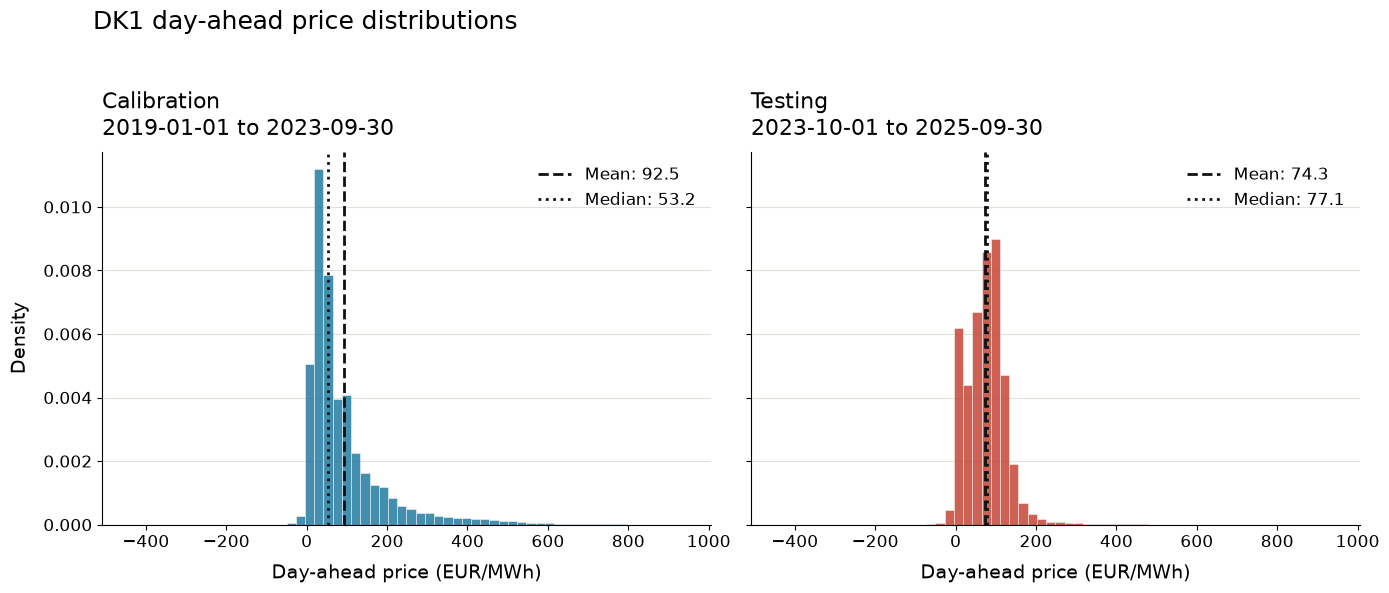

: 

In [ ]:
dk1_price_periods = {
    "Calibration": prices.loc[:CALIBRATION_END, "DK1"].dropna(),
    "Testing": prices.loc[TEST_START:TEST_END, "DK1"].dropna(),
}
combined_dk1_prices = pd.concat(dk1_price_periods.values())
bin_edges = np.histogram_bin_edges(combined_dk1_prices, bins=60)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
period_colours = {"Calibration": "#247ba0", "Testing": "#c44536"}
period_dates = {
    "Calibration": (prices.index.min(), CALIBRATION_END),
    "Testing": (TEST_START, TEST_END),
}

for axis, (period_name, period_prices) in zip(axes, dk1_price_periods.items()):
    start, end = period_dates[period_name]
    colour = period_colours[period_name]
    axis.hist(
        period_prices,
        bins=bin_edges,
        density=True,
        color=colour,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.4,
    )
    axis.axvline(period_prices.mean(), color=INK, linewidth=2, linestyle="--",
                 label=f"Mean: {period_prices.mean():.1f}")
    axis.axvline(period_prices.median(), color=INK, linewidth=2, linestyle=":",
                 label=f"Median: {period_prices.median():.1f}")
    axis.set_title(
        f"{period_name}\n{start:%Y-%m-%d} to {end:%Y-%m-%d}",
        fontsize=16,
        loc="left",
        pad=12,
    )
    axis.set_xlabel("Day-ahead price (EUR/MWh)", fontsize=14, labelpad=9)
    axis.tick_params(axis="both", labelsize=12)
    axis.grid(axis="y", color=GRID, linewidth=0.8)
    axis.set_axisbelow(True)
    axis.spines[["top", "right"]].set_visible(False)
    axis.legend(frameon=False, fontsize=12, loc="upper right")

axes[0].set_ylabel("Density", fontsize=14, labelpad=10)
fig.suptitle("DK1 day-ahead price distributions", fontsize=18, x=0.07, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()